In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [2]:
n_nodes = 3
k = 0.0005

edges = [(0,1), (1,2)]
Ls = [5, 4]
xi = np.array([[0.8, 0.24],[0.25, 0.7]])
# chi = 1 so we ignore it for now.
lmbda = [5, 4]
h = [2*k*lmb for lmb in lmbda]

In [3]:
B0 = np.array([[-1, 1],[1, -1]])*0.25
Bm1 = np.array([[0, 0],[1, -1]])*0.25
B1 = np.array([[-1, 1], [0, 0]])*0.25
D0 = np.array([[1, 0],[0, 1]])*0.5
D1 = np.array([[1, 0], [0, 0]])*0.5
Dm1 = np.array([[0, 0], [0, 1]])*0.5
R = [
    np.array([[1, 1],[-lmbda[0], lmbda[0]]]),
    np.array([[1, 1],[-lmbda[1], lmbda[1]]]),
]
R_inv = [np.linalg.inv(idR) for idR in R]

def roe_matrices(m):
    return [idR @ m @ idR_inv for idR, idR_inv in zip(R, R_inv)]

def beta_coeffs(m):
    """Calculate beta coefficients for all edges"""
    buu_idx = 0,0
    bvu_idx = 1,0
    bvv_idx = 1,1
    buv_idx = 0,1
    roe = roe_matrices(m)
    coeffs = []
    for idx, roe_mat in enumerate(roe):
        buu = 2*roe_mat[buu_idx]
        buv = 2*lmbda[idx]*roe_mat[buv_idx]
        bvu = 2/lmbda[idx]*roe_mat[bvu_idx]
        bvv = 2*roe_mat[bvv_idx]
        coeffs.append([buu, buv, bvu, bvv])

    return coeffs

def gamma_coeffs(m):
    """Calcluate gamma coefficients for all edges"""
    gu_idx = 0,1
    gv_idx = 1,1
    roe = roe_matrices(m)
    coeffs = []
    for idx, roe_mat in enumerate(roe):
        gu = 2*lmbda[idx]*roe_mat[gu_idx]
        gv = 2*roe_mat[gv_idx]
        coeffs.append([gu, gv])

    return coeffs

beta_m1 = beta_coeffs(Bm1)
beta_0 = beta_coeffs(B0)
beta_1 = beta_coeffs(B1)
gamma_m1 = gamma_coeffs(Dm1)
gamma_0 = gamma_coeffs(D0)
gamma_1 = gamma_coeffs(D1)

In [4]:
def n_space_points(L, h):
    """Number of grid points along an edge of length L with space-step h:
    the near-node point (0), the interior points, and the far-node point
    (M_i+1)."""
    n_intervals = round(L / h)
    assert np.isclose(L / h, n_intervals), f"L={L} is not a whole multiple of h={h}"
    return n_intervals + 1


T = 28  # Total simulated time
n_time_steps = round(T / k) + 1
u = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]
v = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]

f = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]
inv_lmbda = [1 / lmb for lmb in lmbda]
k_over_2h = [k / (2 * hi) for hi in h]

In [5]:
def step_interior(u, v, f, n):
    """Advance the interior points of every edge from time-row n to n+1."""
    for i in range(len(edges)):
        u_jm1, u_j, u_jp1 = u[i][n, :-2], u[i][n, 1:-1], u[i][n, 2:]
        v_jm1, v_j, v_jp1 = v[i][n, :-2], v[i][n, 1:-1], v[i][n, 2:]
        f_jm1, f_j, f_jp1 = f[i][n, :-2], f[i][n, 1:-1], f[i][n, 2:]

        bm, b0, b1 = beta_m1[i], beta_0[i], beta_1[i]
        gm, g0, g1 = gamma_m1[i], gamma_0[i], gamma_1[i]

        u[i][n + 1, 1:-1] = (
            u_j
            - k_over_2h[i] * (v_jp1 - v_jm1)
            + lmbda[i] * k_over_2h[i] * (u_jp1 - 2 * u_j + u_jm1)
            + k / 2 * (
                bm[0] * u_jm1 + b0[0] * u_j + b1[0] * u_jp1
                + inv_lmbda[i] * (bm[1] * v_jm1 + b0[1] * v_j + b1[1] * v_jp1)
                + inv_lmbda[i] * (gm[0] * f_jm1 + g0[0] * f_j + g1[0] * f_jp1)
            )
        )

        v[i][n + 1, 1:-1] = (
            v_j
            - lmbda[i] ** 2 * k_over_2h[i] * (u_jp1 - u_jm1)
            + lmbda[i] * k_over_2h[i] * (v_jp1 - 2 * v_j + v_jm1)
            + k / 2 * (
                lmbda[i] * (bm[2] * u_jm1 + b0[2] * u_j + b1[2] * u_jp1)
                + bm[3] * v_jm1 + b0[3] * v_j + b1[3] * v_jp1
                + (gm[1] * f_jm1 + g0[1] * f_j + g1[1] * f_jp1)
            )
        )

    return u, v

In [6]:
M = [arr.shape[1] - 2 for arr in u]  # interior-point count per edge

internal_node = 1
in_node, out_node = 0, 2
I_p = [j for j, e in enumerate(edges) if e[1] == internal_node]
O_p = [j for j, e in enumerate(edges) if e[0] == internal_node]
I_out = [j for j, e in enumerate(edges) if e[0] == in_node]
O_out = [j for j, e in enumerate(edges) if e[1] == out_node]

def characteristic(u_val, v_val, lmb):
    """u_+, u_- from u = u_- + u_+, v = lmbda*(u_+ - u_-), evaluated directly
    at a point - no full-array characteristic-variable history is kept,
    since only the points nearest each node are ever needed."""
    return (u_val + v_val / lmb) / 2, (u_val - v_val / lmb) / 2

# q, prefactor: time-invariant per boundary edge (depend only on the fixed
# mesh/coupling data), so computed once here rather than inside the
# per-time-step node-coupling loop.
q = [2 * lmbda[i] / h[i] for i in range(len(edges))]
prefactor = {
    i: h[i] / (h[i] + sum(h[j] * xi[j, i] for j in I_p + O_p))
    for i in I_p + O_p
}

In [7]:
# Chemoattractant diffusion model
# phi_t - D*phi_xx = a*u - b*phi
D = [1.0 for _ in range(len(edges))]  # Diffusion coefficient of the chemo-attractant
a = [1.0 for _ in range(len(edges))]  # Production rate coefficient (from u)
b = [1 for _ in range(len(edges))]  # Decay rate coefficient
kappa = np.array([[0., 1.], [1., 0.]])  # Internal-node flux-coupling weights

m = [n_space_points(Ls[i], h[i]) for i in range(len(edges))]  # total grid points per edge
offsets_phi = np.concatenate(([0], np.cumsum(m))).astype(int)


def build_phi_system():
    """Assemble the global sparse Crank-Nicolson system for phi across all
    edges: A_phi @ phi[n+1] = B_phi @ phi[n] + source(u[n], u[n+1]).

    Boundary rows (leaf no-flux and internal-node flux-continuity) are pure
    algebraic constraints on phi[n+1], so they are zero in B_phi.

    A_phi is time-invariant (D, a, b, h, k, kappa never change during the
    simulation), so it is factorised once here and reused every time step.
    """
    n_total = offsets_phi[-1]
    A_phi = sp.lil_matrix((n_total, n_total))
    B_phi = sp.lil_matrix((n_total, n_total))

    for i in range(len(edges)):
        Dkh = D[i] * k / h[i] ** 2
        off = offsets_phi[i]
        for j in range(1, m[i] - 1):
            A_phi[off + j, off + j] = 1 + Dkh + b[i] * k / 2
            A_phi[off + j, off + j - 1] = -Dkh / 2
            A_phi[off + j, off + j + 1] = -Dkh / 2

            B_phi[off + j, off + j] = 1 - Dkh - b[i] * k / 2
            B_phi[off + j, off + j - 1] = Dkh / 2
            B_phi[off + j, off + j + 1] = Dkh / 2

    # Leaf boundary rows: no-flux, one-sided quadratic extrapolation
    for i in I_out:
        off = offsets_phi[i]
        A_phi[off, off] = 1
        A_phi[off, off + 1] = -4 / 3
        A_phi[off, off + 2] = 1 / 3

    for i in O_out:
        end = offsets_phi[i] + m[i] - 1
        A_phi[end, end] = 1
        A_phi[end, end - 1] = -4 / 3
        A_phi[end, end - 2] = 1 / 3

    # Internal-node coupling rows: flux continuity weighted by kappa
    for i in I_p:
        end = offsets_phi[i] + m[i] - 1
        A_phi[end, end] = 1 + 2 / 3 * h[i] / D[i] * kappa[i, :].sum()
        A_phi[end, end - 1] = -4 / 3
        A_phi[end, end - 2] = 1 / 3
        for j in I_p + O_p:
            if kappa[i, j] == 0:
                continue
            near = offsets_phi[j] + m[j] - 1 if j in I_p else offsets_phi[j]
            A_phi[end, near] -= 2 / 3 * h[i] / D[i] * kappa[i, j]

    for i in O_p:
        off = offsets_phi[i]
        A_phi[off, off] = 1 + 2 / 3 * h[i] / D[i] * kappa[i, :].sum()
        A_phi[off, off + 1] = -4 / 3
        A_phi[off, off + 2] = 1 / 3
        for j in I_p + O_p:
            if kappa[i, j] == 0:
                continue
            near = offsets_phi[j] + m[j] - 1 if j in I_p else offsets_phi[j]
            A_phi[off, near] -= 2 / 3 * h[i] / D[i] * kappa[i, j]

    return spla.splu(A_phi.tocsc()), B_phi.tocsr()


A_phi_lu, B_phi = build_phi_system()


def solve_phi(u, phi, n):
    """Advance phi from time row n to n+1 via the pre-factorised global CN
    system, using u[n] and u[n+1] (already known by this point in `step`)
    as the source."""
    phi_n = np.concatenate([phi[i][n, :] for i in range(len(edges))])
    source = B_phi @ phi_n

    for i in range(len(edges)):
        off = offsets_phi[i]
        local = slice(1, m[i] - 1)
        source[off + 1:off + m[i] - 1] += a[i] * k / 2 * (u[i][n, local] + u[i][n + 1, local])

    phi_next = A_phi_lu.solve(source)

    for i in range(len(edges)):
        off = offsets_phi[i]
        phi[i][n + 1, :] = phi_next[off:off + m[i]]

    return phi

In [8]:
def step_node_outgoing(u, v, f, n):
    """Compute the characteristic travelling toward the internal node from
    each connected edge: u_{+,i}^{M_i+1} for i in I_p, u_{-,i}^{0} for i in
    O_p. These are the quantities the xi coupling law combines into each
    edge's incoming characteristic. Evaluated directly from (u, v) at just
    the two points nearest the node - no full-array characteristic history
    is kept."""
    bd_char = {}
    for i in I_p:
        b1, bm, g1, gm = beta_1[i], beta_m1[i], gamma_1[i], gamma_m1[i]
        Mi = M[i]
        u_p_end, u_m_end = characteristic(u[i][n, Mi + 1], v[i][n, Mi + 1], lmbda[i])
        u_p_in, u_m_in = characteristic(u[i][n, Mi], v[i][n, Mi], lmbda[i])

        bd_char[i] = prefactor[i] * (
            u_p_end * (1 - k * b1[0] - k * b1[1])
            + u_m_end * (1 - k * q[i] - k * b1[0] + k * b1[1])
            + k * u_p_in * (q[i] + bm[0] + bm[1])
            + k * u_m_in * (bm[0] - bm[1])
            - k / lmbda[i] * (g1[0] * f[i][n, Mi + 1] - gm[0] * f[i][n, Mi])
        )

    for i in O_p:
        b1, bm, g1, gm = beta_1[i], beta_m1[i], gamma_1[i], gamma_m1[i]
        u_p0, u_m0 = characteristic(u[i][n, 0], v[i][n, 0], lmbda[i])
        u_p1, u_m1 = characteristic(u[i][n, 1], v[i][n, 1], lmbda[i])

        bd_char[i] = prefactor[i] * (
            u_p0 * (1 - q[i] * k - k * bm[0] - k * bm[1])
            + u_m0 * (1 - k * bm[0] + k * bm[1])
            + k * u_p1 * (b1[0] + b1[1])
            + k * u_m1 * (q[i] + b1[0] - b1[1])
            + k / lmbda[i] * (g1[0] * f[i][n, 1] - gm[0] * f[i][n, 0])
        )

    return bd_char

def step_node_coupling(u, v, bd_char, n):
    """xi coupling law at the internal node: combine each edge's outgoing
    characteristic (from step_node_outgoing) into every edge's incoming
    characteristic, then reconstruct u, v at each boundary point from its
    own pair of characteristics."""
    for i in I_p:
        u_p_end = bd_char[i]
        u_m_end = (
            sum(xi[i, j] * bd_char[j] for j in I_p)
            + sum(xi[i, j] * bd_char[j] for j in O_p)
        )
        u[i][n + 1, M[i] + 1] = u_p_end + u_m_end
        v[i][n + 1, M[i] + 1] = lmbda[i] * (u_p_end - u_m_end)

    for i in O_p:
        u_m0 = bd_char[i]
        u_p0 = (
            sum(xi[i, j] * bd_char[j] for j in I_p)
            + sum(xi[i, j] * bd_char[j] for j in O_p)
        )
        u[i][n + 1, 0] = u_p0 + u_m0
        v[i][n + 1, 0] = lmbda[i] * (u_p0 - u_m0)

    return u, v

def step_bd_1(u, v, n):
    """No-flux (v = 0) condition at the outer leaf nodes, complementing
    step_bd_outer_u's u update there."""
    for i in I_out:
        v[i][n + 1, 0] = 0
    for i in O_out:
        v[i][n + 1, -1] = 0
    return u, v

def step_bd_outer_u(u, v, f, n):
    """u at the two outer (leaf) nodes, complementing step_bd_1's v = 0
    there."""
    for i in I_out:
        b1, bm, g1, gm = beta_1[i], beta_m1[i], gamma_1[i], gamma_m1[i]
        u[i][n + 1, 0] = (
            (1 - lmbda[i] * k / h[i] - k * bm[0]) * u[i][n, 0]
            + k * (lmbda[i] / h[i] + b1[0]) * u[i][n, 1]
            - k * (1 / h[i] - b1[1] / lmbda[i]) * v[i][n, 1]
            + k / lmbda[i] * (g1[0] * f[i][n, 1] - gm[0] * f[i][n, 0])
        )

    for i in O_out:
        b1, bm, g1, gm = beta_1[i], beta_m1[i], gamma_1[i], gamma_m1[i]
        Mi = M[i]
        u[i][n + 1, Mi + 1] = (
            (1 - lmbda[i] * k / h[i] - k * bm[0]) * u[i][n, Mi + 1]
            + k * (lmbda[i] / h[i] + b1[0]) * u[i][n, Mi]
            + k * (lmbda[i] / h[i] + bm[1] / lmbda[i]) * v[i][n, Mi]
            - k / lmbda[i] * (g1[0] * f[i][n, Mi + 1] - gm[0] * f[i][n, Mi])
        )

    return u

def compute_f(u, v, phi, f, n):
    """Chemotactic flux f = phi_x * u, using central differences in the
    interior and one-sided differences at each edge's two endpoints."""
    for i in range(len(edges)):
        p = phi[i][n, :]
        phi_x = np.zeros_like(p)
        phi_x[1:-1] = (p[2:] - p[:-2]) / (2 * h[i])
        phi_x[0] = (-3 * p[0] + 4 * p[1] - p[2]) / (2 * h[i])
        phi_x[-1] = (p[-3] - 4 * p[-2] + 3 * p[-1]) / (2 * h[i])
        f[i][n, :] = phi_x * u[i][n, :]
    return f

def step(u, v, f, phi, n):
    """Advance the whole network by one time step, n -> n+1."""
    u, v = step_interior(u, v, f, n)
    u, v = step_bd_1(u, v, n)

    bd_char = step_node_outgoing(u, v, f, n)
    u, v = step_node_coupling(u, v, bd_char, n)
    u = step_bd_outer_u(u, v, f, n)

    phi = solve_phi(u, phi, n)
    f = compute_f(u, v, phi, f, n + 1)
    return u, v, f, phi

In [9]:
x = [np.linspace(0, Ls[i], n_space_points(Ls[i], h[i])) for i in range(len(edges))]

u = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]
v = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]
f = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]
phi = [np.zeros((n_time_steps, n_space_points(Ls[i], h[i]))) for i in range(len(edges))]

for i in range(len(edges)):
    u[i][0, :] = 20 + np.cos(np.pi * x[i] / Ls[i])
f = compute_f(u, v, phi, f, 0)

for n in range(n_time_steps - 1):
    u, v, f, phi = step(u, v, f, phi, n)

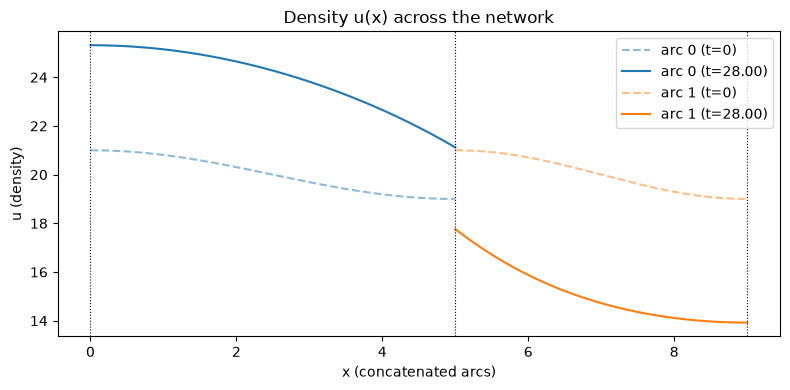

In [10]:
offsets = np.concatenate(([0], np.cumsum(Ls)))

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(edges)):
    x_global = x[i] + offsets[i]
    ax.plot(x_global, u[i][0], "--", color=f"C{i}", alpha=0.5, label=f"arc {i} (t=0)")
    ax.plot(x_global, u[i][-1], color=f"C{i}", label=f"arc {i} (t={(n_time_steps - 1) * k:.2f})")

for boundary in offsets:
    ax.axvline(boundary, color="k", linestyle=":", linewidth=0.8)

ax.set_xlabel("x (concatenated arcs)")
ax.set_ylabel("u (density)")
ax.set_title("Density u(x) across the network")
ax.legend()
plt.tight_layout()
plt.show()

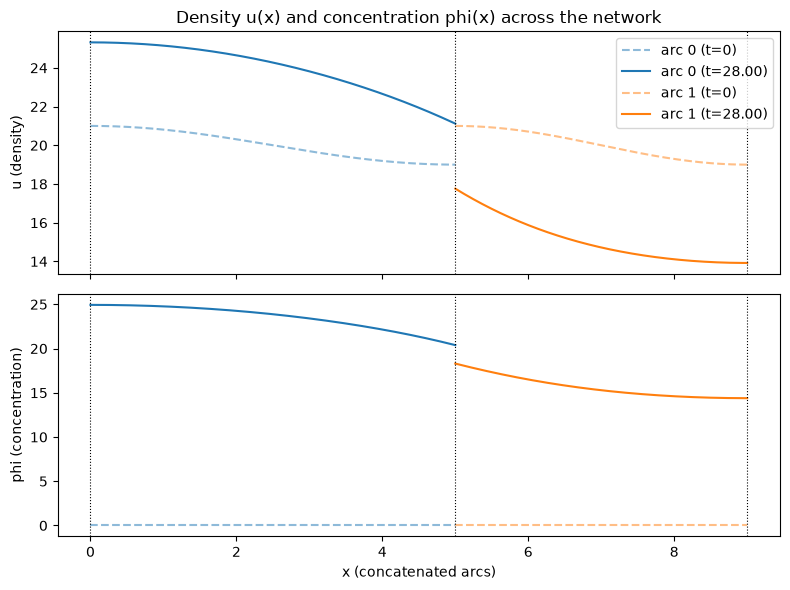

In [11]:
fig, (ax_u, ax_phi) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for i in range(len(edges)):
    x_global = x[i] + offsets[i]
    ax_u.plot(x_global, u[i][0], "--", color=f"C{i}", alpha=0.5, label=f"arc {i} (t=0)")
    ax_u.plot(x_global, u[i][-1], color=f"C{i}", label=f"arc {i} (t={(n_time_steps - 1) * k:.2f})")
    ax_phi.plot(x_global, phi[i][0], "--", color=f"C{i}", alpha=0.5)
    ax_phi.plot(x_global, phi[i][-1], color=f"C{i}")

for boundary in offsets:
    ax_u.axvline(boundary, color="k", linestyle=":", linewidth=0.8)
    ax_phi.axvline(boundary, color="k", linestyle=":", linewidth=0.8)

ax_u.set_ylabel("u (density)")
ax_u.set_title("Density u(x) and concentration phi(x) across the network")
ax_u.legend()

ax_phi.set_ylabel("phi (concentration)")
ax_phi.set_xlabel("x (concatenated arcs)")

plt.tight_layout()
plt.show()